# Oblig 2b – Nevrale nettverk

**Våren 2026**

Det er en god idé å lese gjennom hele oppgavesettet før dere setter i gang. Dersom dere har spørsmål så kan dere:

- gå i gruppetime,
- spørre på Discourse
- eller sende epost til in1160-support@ifi.uio.no dersom alternativene over av en eller annen grunn ikke passer for spørsmålet.

## Innlevering

Oppgaven leveres innen 25. mars klokken 23.59 i [Devilry](https://devilry.ifi.uio.no/).

Innleveringen skal bestå av én Jupyter notebook med både kode og tilhørende forklaringer. Før innlevering skal du kjøre gjennom hele notebooken, før du lagrer siste gang. Den bør kjøre uten å feile og vise alt som skal være med.

Vi understreker at innlevering av kode alene ikke er nok for å bestå oppgaven – vi forventer at notebooken også skal inneholde kommentarer (på norsk eller engelsk) på hva dere har gjort og begrunnelser for valgene dere har tatt underveis. La enhver oblig bli en trening i å formidle forskning. Bruk helst hele setninger, og matematiske formler om nødvendig. Resultater skal presenteres i tabeller på en oversiktlig måte. Det å forklare med egne ord, bruke begreper vi har gått gjennom på forelesningene og å forklare og reflektere over løsningene deres er en viktig del av læringsprosessen – ta det på alvor!

Når det gjelder bruk av generative prateroboter (ChatGPT og lignende): Dere kan bruke dem som en "sparringspartner", for eksempel for å forklare noe dere ikke helt har forstått. Dere har imidlertid ikke lov til å bruke dem til å generere løsninger (enten delvis eller fullstendig) til noen av oppgavene. Funksjoner for automatisk skriving av kode, som Copilot i VS Code, må derfor også være deaktivert mens dere jobber på obligen.

Bruker dere KI-verktøy vil vi også at dere kort beskriver hvordan dere har brukt dem under arbeidet med oppgaven.

Det er ikke mulighet for omlevering av obliger som ikke bestås.

**Poeng:** Obligen gir maksimalt 25 poeng. For å bestå kreves det totalt 30 av 50 poeng fra oblig 2a og 2b tilsammen. Poengfordelingen er markert i overskriften til oppgaven med `p`.

**Merk:** Obligene er nye, så vi oppdaterer skrivefeil og liknende fortløpende. For å få den nyeste endringene kan dere kjøre `git pull` i terminalen (gitt at dere har klonet repositoriet). Dersom dere har endret en fil med samme navn kan dere få en *merge conflict*. For å unngå dette kan dere endre navnet på filen og kjøre `git pull` på nytt. En ny fil med det originale navnet vil da dukke opp, der endringene er gjort.
For eksempel kan dere endre navn på denne fila fra `oblig_2b.ipynb` til `oblig_2b_<brukernavn>.ipynb`.

Finner dere noe dere tror er feil i obligen, må dere gjerne si ifra på [Discourse](https://discourse.uio.no/c/in1160-26v/820).


## Bakgrunn

I denne obligen skal vi bruke nevrale nettverk til å klassifisere håndskrevne sifre fra det legendariske [MNIST datasettet](https://en.wikipedia.org/wiki/MNIST_database). Dette har vært et av de viktigste datasettene i utviklingen av dyplæring fra starten av 90-tallet til starten av 2010-tallet. Vi skal bruke et enkelt forovermatet nevralt nettverk (feed forward neural network), der blant annet foroverfasen, aktiveringsfunksjoner og evaluering skal implementeres. Obligen ser på hvordan *tilbakepropagering* (backpropagation) og *stokastisk gradientnedstigning* (stochastic gradient descent (SGD)) fungerer, men implementasjonen av dette er ikke en del av obligen og koden for det blir gitt ferdig implementert.

Det er *sterkt anbefalt* å se igjennom de tre første videoene i [denne introduksjonen til nevrale nettverk](https://www.youtube.com/watch?v=aircAruvnKk&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) før dere begynner på denne obligen. Denne videoserien av 3Blue1Brown (Grant Sanderson) bruker eksepsjonelle animasjoner til å introdusere bildegjenkjenning, nevrale nettverk og SGD på en pedagogisk og vakker måte. Det vil bli betydelig enklere å fullføre denne obligen med denne kunnskapen. [Denne videoen](https://www.youtube.com/watch?v=GkiITbgu0V0) kan også være til nytte.


In [2]:
import numpy as np

from plotting import plot_mislabeled_mnist_images, plot_random_mnist_images, plot_worst_predicted_mnist_images
from tests2b import (
    test_calculate_accuracy,
    test_calculate_multiclass_cross_entropy_loss,
    test_count_parameters,
    test_forward_pass,
    test_predict,
    test_relu_class,
    test_sigmoid_class,
)
from utils2b import IdentityActivation, NeuralNetwork, integer_one_hot_encode, load_mnist_data, softmax

## 1 - MNIST [Totalt 2p]

### Litt historisk kontekst

La oss se litt nærmere på datasettet vi skal bruke. MNIST (Modified National Institute of Standards and Technology database) inneholder 60 000 treningsbilder av håndtegnete sifre annotert med 0-9 (de sanne verdiene), og 10 000 tilsvarende testbilder. Bildene er i svart-hvitt og har en oppløsning på 28 x 28 piksler. Dataene har opprinnelse fra den amerikanske etaten NIST (National Institute of Standards and Technology) og ble prosessert av forskere i AT&T Bell labs på 90-tallet for å gjøre dataene mer standardiserte og konsekvente. Datasettet ble utviklet for å gjøre framgang i gjenkjenning av håndskrevne tall og ord, som var et viktig og stort sett uløst problem på den tiden. Bildene i treningsdataene er skrevet av ansatte i amerikanske byråer, mens bildene i testsetet er skrevet av elever på videregående nivå (high school).

Datasettet førte til en av de tidligste applikasjonene av nevrale nettverk. På denne tiden hadde nevrale nettverk fortsatt et begrenset bruksområde og de dominerende maskinlæringsmetodene baserte seg på manuelt konstruerte trekk (features) og modeller som k-NN, lineære klassifikatorer og support vector machines (SVM). Nevrale nettverk krever ofte mye data for å fungere, ofte mer enn andre maskinlæringsmetoder, og MNIST var en viktig brikke i utviklingen av nevrale nettverk i tiårene etterpå. Allikevel oppnådde ikke dyplæring bred anerkjennelse før i 2012, da det nevrale nettverket *AlexNet* vant bildegjenkjennelseskonkurransen *ImageNet*, som inneholder mye mer realistiske bilder med høyere oppløsning og flere klasser.

MNIST er i dag regnet som et svært enkelt datasett, tilsvarende et "Hello world"-datasett for maskinlæring. Derfor er det ikke lenger brukt for utvikling av dyplæring, siden modeller kan oppnå svært bra resultat selv om de er ineffektive. Dette gjør det heldigvis perfekt for å komme i gang med dyplæring. Vi skal bruke et enkelt forovermatet nevralt nettverk vi lager fra scratch med NumPy og trenger ingen flere fancy metoder for å få det til å fungere. Samtidig er problemet vanskelig nok til at det ikke er trivielt å løse med tradisjonelle og regelbaserte metoder eller trekk konstruksjon (feature engineering).

### MNIST-datasettet

La oss se på hvordan dataene i datasettet faktisk ser ut. Funksjonen `load_mnist_data()` fra `utils2b.py` kan brukes til å laste inn datasettet, og det er diverse funksjoner for å plotte det i `plotting.py`. La oss prøve:

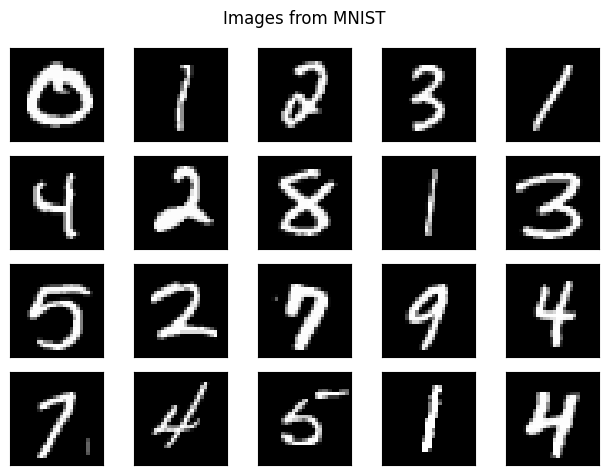

Shape of dataset: (50000, 784)


In [5]:
mnist_data = load_mnist_data(scale_x_data=False)
x_train = mnist_data["x_train"]
y_train = mnist_data["y_train"]

plot_random_mnist_images(images=x_train, n_random=20, n_cols=5, title="Images from MNIST")
print(f"Shape of dataset: {x_train.shape}")


Over kan dere se noen eksempler på bildene. Funksjonen `load_mnist_data()` gir både trenings-, validerings- og testdata. Som man kan se fra dimensjonene til `x_train` er det 50 000 bilder i treningsdataene, mens det er 10 000 bilder i validerings- og testdataene. Hvert bilde er representert som en liste av 784 tall, som tilsvarer oppløsningen av 28 x 28 piksler. Hver piksel er et heltall mellom 0 og 255, der 0 representerer helt svart og 255 representerer helt hvitt. Bilder med farge har som regel tre kanaler (channels), et for rødt, grønt og blått, alle med fargestyrke mellom 0 og 255. Om disse tre har lik styrke får man gråtoner, så for svart-hvitt bilder trenger man bare én kanal.

De sanne verdiene inneholder tall mellom 0 og 9 som representerer hvilket siffer som er på det tilsvarende bildet. 

Når vi gir dataene som input til nevrale nettverk er det ofte fint å skalere den, slik at man ikke ender opp med for store verdier tidlig i treningen som skaper instabilitet. Det kan man enkelt gjøre ved å dele på 255, slik at alle pikselverdiene blir mellom 0 og 1. Dersom argumentet `scale_x_data=True` blir sendt til `load_mnist_data()` blir dataene skalert slik.

**Oppgave 1 [2p]**: La oss gjøre noen oppgaver relatert til datasettet for å bli bedre kjent med det.

- a) Hvor mange bilder i treningsettet representerer sifferet "9"?
- b) Hva er den gjennomsnittlige pikselverdien av alle pikslene av alle bildene i treningsdataene?

In [6]:
# a)

# b)

**[Bonus]**: De første nevrale nettverkene trent på MNIST, kalt *LeNet* (oppkalt etter *Yann LeCun*, som er en av de viktigste forskerne innenfor dyplæring og var med å utvikle MNIST), var *convolutional neural networks* (CNN). Dette er nevrale nettverk som bruker en operasjon kalt *konvolusjoner* i de tidligste lagene i nettverket. Konvolusjoner har lenge blitt brukt i bildebehandling og kan blant annet bli brukt til å påføre filtere, gjøre bilder uskarpe og finne kanter i bilder (alt uten maskinlæring). I CNN-er blir parameterne til konvolusjonen funnet gjennom trening, som gir mange fordeler. I "fully connected feed-forward" nevrale nettverk må vi ha en vekt (parameter) mellom hver av pikselverdiene og hver av nodene i det første skjulte laget. Dette fungerer for MNIST som har svært få piksler, men for mer realistiske datasett blir dette fort upraktisk mange parametere. CNN-er kan bruke langt færre parametere og har andre fordeler som at de bedre utnytter den to-dimensjonale strukturen i bilder. Om dere er interessert i å lære mer kan dere se [denne videoen](https://www.youtube.com/watch?v=8rrHTtUzyZA) for en visuell forklaring av hvordan konvolusjon fungerer på bilder. Dere kan lære om CNN-er i faget IN3310.

## 2 - Nevrale nettverk [Totalt 13p]

Vi skal bruke forovermatede nevrale nettverk til å klassifisere bildene i MNIST. Vi har prøvd å lage denne obligen slik at dere vil få en best mulig introduksjon til nevrale nettverk på et detaljert implementasjonsnivå, samtidig som dere skal slippe å knote med for mye med likninger og indekseringer. Derfor har vi valgt å gi dere ferdig kode for de mest intrikate stegene, og har latt de delene vi tror gir best læring for minst mulig knoting være opp til dere å kode. Dere trenger derfor ikke å implementere tilbakepropagering, SGD og vektinitialisering, men dere skal blant annet implementere foroverfasen, prediksjon, aktiveringsfunksjoner og noen funksjoner for evaluering.


### 2.1 - Aktiveringsfunksjoner [2p]

Vi starter med å implementere aktiveringsfunksjonene vi skal bruke, Sigmoid og ReLU (rectified linear unit). Aktiveringsfunksjoner blir brukt i foroverfasen, mens den deriverte til funksjonene blir brukt i bakoverfasen. Dette er praktisk å implementere som en klasse uten klassevariabler.

La oss se litt på aktiveringsfunksjonene og deres deriverte. Som tidligere nevnt er det ikke pensum å regne ut deriverte uttrykk, men det er pensum å forstå hva de deriverte er og hvorfor vi bruker dem. Kort sagt beskriver den deriverte til en funksjon hvor raskt funksjonen vokser eller minsker i et bestemt punkt. 
Vi noterer den deriverte av funksjonen $f(x)$ som $f'(x)$. 
Hvis funksjonen vår er $f(x)=3x+0.5$, er den deriverte funksjonen $f'(x)=3$, fordi $f(x)$ alltid stiger med $3$.

I bakoverfasen vil vi derivere tapfunksjonen med hensyn på parameterne, slik at vi kan finne ut hvordan parameterne burde bli justert for at tapet skal minske mest mulig. Siden aktiveringsfunksjonen er med på å predikere (foroverfasen), vil deres deriverte dukke opp i oppdateringsregelen. Dere skal altså ikke implementere oppdateringsregelen (tilbakepropagering og SGD), men implementasjonen dere skal bruke avhenger av at dere implementerer prediksjon og den deriverte til aktiveringsfunksjonene.

Sigmoid, som vi implementerte i oblig 2a i forbindelse med logistisk regresjon, er definert ved følgende:

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

Ved å bruke derivasjonsregelen til ganging eller deling og litt utregning, kan man uttrykke den deriverte til sigmoid ved funksjonen selv:

$$\sigma'(x) = \sigma(x)(1 - \sigma(x))$$

ReLU (rectified linear unit) er definert ved:

$$\text{ReLU}(x) = \max(x, 0)$$

Altså $\text{ReLU}(x) = x$ for alle $x > 0$, og 0 ellers. Den deriverte blir:

$$
\text{ReLU}'(x) = 
\begin{cases}
1 & \text{if } x > 0 \\
0 & \text{if } x \leq 0
\end{cases}
$$

**Oppgave 2.1**: Implementer aktiveringsfunksjonene sigmoid og ReLU og deres deriverte i klassene gitt under. Metoden `__call__()` skal returnere et kall på funksjonene, mens metoden `diff()` skal returnere den deriverte. Inputet skal her være en to-dimensjonal array, av størrelse `[n x p]`, der `n` er antall datapunkter og `p` er antall noder i laget (som for første lag er lik antall trekk i inndataene). Outputet skal derfor også være av samme dimensjon. Som i oblig 2a kan dere velge om dere vil vektorisere eller loope eksplisitt, men her blir det nok betydelig enklere (og fortsatt mer effektivt) å vektorisere.

- a) Implementer klassen `Sigmoid`. **Hint**: Siden den deriverte til sigmoid er definert som et uttrykk av seg selv, kan dere bruke implementasjonen deres i `__call__()`, som kan kalles med `self(x_data)`.
- b) Implementer ReLU klassen. Pass spesielt på at den deriverte returnerer en NumPy-array med typen `float32` (flyttall representert med 32 bits, som er datatypen vanligvis brukt i maskinlæring). Dere kan bruke `my_array.astype(np.float32)` for dette, gitt et array `my_array`.

In [ ]:
class Sigmoid:
    def __call__(self, x_data):
        """
        Performs the sigmoid function on every element in `x_data`.
        Sigmoid is defined as 1 / (1 + exp(-x)).

        Arguments:
            x_data (np.array): [n x p]-shaped array of `n` inputs and `p` features with float values.

        Returns:
            np.array: [n x p]-shaped array of with sigmoid applied to the elements in `x_data`.
        """
        pass

    def diff(self, x_data):
        """
        Returns derivative of the sigmoid functions, s'(x) = s(x) * (1 - s(x))

        Arguments:
            x_data (np.array): [n x p]-shaped array of `n` inputs and `p` features with float values.

        Returns:
            np.array: [n x p]-shaped array of the derivatives of the sigmoid function.
        """
        pass


test_sigmoid_class(input_class=Sigmoid)

Failed: `test_sigmoid_class`. Not implemented (returned `None`) in forward pass.


In [9]:
class ReLU:
    def __call__(self, x_data):
        """
        Performs the ReLU function on every element in `x_data`.
        ReLU is defined as ReLU(x) = max(0, x).

        Arguments:
            x_data (np.array): [n x p]-shaped array of `n` inputs and `p` features with float values.

        Returns:
            np.array: [n x p]-shaped array of the with ReLU applied to `x_data`.
        """
        pass

    def diff(self, x_data):
        """
        Returns derivative of the ReLU function, which is 1 for elements larger than 0 and 0 if not.

        Arguments:
            x_data (np.array): [n x p]-shaped array of `n` inputs and `p` features with float values.

        Returns:
            np.array: [n x p]-shaped array of the derivatives of the ReLU function.
        """
        pass


test_relu_class(input_class=ReLU)

Failed: `test_relu_class`. Not implemented (returned `None`) in forward pass.


**Tips**: Metoden `__call__` blir kalt dersom en instans av klassen blir brukt som en funksjon. Om dere for eksempel lager en instansvariabel `sigmoid = Sigmoid()`, kan dere bruke sigmoid-funksjonen med `sigmoid(x)`, som bak kulissene vil kalle `__call()__` og gi det samme resultatet som `sigmoid.__call__(x)`. For å bruke den deriverte kan man kalle `sigmoid.diff(x)`.

### 2.2 - Parametere [2p]

I de neste oppgavene skal vi bruke klassen `NeuralNetwork` til å implementere nevrale nettverk. Klassen inneholder noen metoder som er ferdig implementert og noen som skal implementeres som del av denne obligen. La oss starte med å opprette en instans av klassen. Konstruktøren tar inn to argumenter, en liste med antall noder i hvert lag og en liste med tilsvarende aktiveringsfunksjoner.

In [ ]:
neural_network = NeuralNetwork(
    layer_sizes=[784, 32, 16, 10],
    activation_functions=[ReLU(), ReLU(), IdentityActivation()],
)

Her lager vi et nevralt nettverk med fire lag: Et input-lag med 784 noder, som tilsvarer oppløsningen i MNIST på 28 x 28 piksler, et skjult lag med 32 noder, et til skjult lag med 16 noder, og til slutt et output-lag med 10 noder, som tilsvarer antall klasser i MNIST.

Lagene trenger en aktiveringsfunksjon for å regne ut aktiveringene i hvert lag, bortsett input-laget (siden aktiveringene i det første laget er lik inputet). Disse funksjonene må være implementert som en klasse, slik vi gjorde i forrige seksjon, med `__call__()` som kaller funksjonen og `diff()` som kaller dens deriverte. Vi bruker `IdentityActivation()` i siste lag, som returnerer det samme som den får som input, siden aktiveringsfunksjonen for output-laget `softmax` blir brukt implisitt i bakoverfasen og som del av evalueringsfunksjonen vår senere.

Konstruktøren til klassen er ferdiglaget og initialiserer parameterne. I lineære modeller initialiseres ofte parameterne til 0-ere, men trening av dype nevrale nettverk er litt mer intrikat og dette kan føre til dårlig trening. Derfor initialiseres vektene til *små tilfeldige positive og negative verdier*.

I tillegg setter konstruktøren noen klassevariabler dere vil trenge senere, som `self.layer_sizes` (samme som argumentet til konstruktøren med samme navn), `self.n_layers` (antall lag, lengden av `self.layer_sizes`) og `self.activation_functions` (samme som argumentet til konstruktøren med samme navn). I tillegg blir vektene og konstantleddene lagret i henholdsvis klassevariablene `self.weights` og `self.biases`. Disse variablene er lister, der element nummer *i* tilsvarer vektene eller konstantleddene for lag nummer *i*.

I neste oppgave skal vi bli litt mer kjent med formatet til vektene og konstantleddene.

**Oppgave 2.2**: Lag en metode `count_parameters()` som returnerer antall parametere (vekter pluss konstantledd) i modellen.

**Hint**: Dette krever å iterere over `self.weights` og `self.biases`. Hvert element i `self.weights` er en to-dimensjonal NumPy array. Dimensjonene i lag $i$ kan nås ved `self.weights[i].shape` og tilsvarende for konstantleddene. 

**Hint**: For antall konstantledd, bruk `self.biases[i].shape[1]`. For antall vekter, gang nulte og første dimensjon sammen.

In [6]:
def count_parameters(self):
    """
    Counts the amount of trainable parameters in the model. This is the sum of nodes in each layers (weights)
    plus the biases.

    Returns:
        int: The amount of trainable parameters in the model.
    """
    pass


NeuralNetwork.count_parameters = count_parameters
test_count_parameters(input_class=NeuralNetwork)

Failed: `test_count_parameters`. Not implemented (`None` returned).


### 2.3 - Foroverfasen (forward pass) [6p]

Vi skal nå implementere foroverfasen (forward pass). Dette steget sender et input gjennom alle lagene i nettverket. For MNIST datasettet vil inputet være en liste av lengde 784, som representerer et svart-hvitt bilde av oppløsning 28 x 28, og outputet vil være en liste av lengde 10, som representerer et tall for hver av de 10 mulige sifrene. Når vi bruker modellen til klassifisering vil vi velge sifferet tilsvarende den av de 10 output-nodene som har høyest verdi. Foroverfasen blir også brukt under trening, der vi altererer mellom foroverfasen og bakoverfasen.

La oss se nærmere på hva som skjer i foroverfasen. I hvert lag ganger vi aktiveringene av nodene i det forrige laget med vektene fra det neste laget, plusser på konstantleddet (biasen) og sender dette gjennom en aktiveringsfunksjon. I utgangspunktet er dette ganske enkle operasjoner, men man må konsentrere seg litt for få indeksene til vektene og lagene korrekt. La oss kort gjennomgå presis notasjon for dette. En nøyere gjennomgang er gitt i oppgave 7.2 i ukesoppgaver for uke 7.

Vi starter med notasjonen av vektene våre. Når vi går fra et lag $l$ til det neste laget $l + 1$, har vi én vekt mellom hver node i lag $l$ og hver node i lag $l + 1$. Disse vektene blir representert i en *matrise*, altså en todimensjonal tabell, som vi kaller for $W^{(l + 1)}$. Her er bruker vi $(l + 1)$ til å representere at dette er vektene for lag nummer $l + 1$, så $l + 1$ er altså *ikke* en eksponent. Elementet $w^{(l + 1)}_{j, k}$ vil være vekten i rad $j$ og kolonne $k$ i denne matrisen. I notasjonen vår vil dette representere vekten fra node nummer $k$ i lag nummer $l$ til node $j$ i lag nummer $l + 1$. Dette blir illustrert med noen eksempler i figuren under.

<p align="center">
  <img src="bilder/neural_network_4_2_3_with_weights.png" alt="Nevralt nettverk med vekter"/ height=400>
</p>

Illustrasjonen viser et eksempel på et enkelt nevralt nettverk med fire noder i inputlaget, to noder i det eneste skjulte laget (lag 2) og tre noder i outputlaget. Vi får to vekt-matriser, $W^{(2)}$ og $W^{(3)}$. Disse kan vi notere som:

$$
W^{(2)} =
\begin{bmatrix}
w^{(2)}_{1, 1} & w^{(2)}_{1, 2} & w^{(2)}_{1, 3} & w^{(2)}_{1, 4} \\
w^{(2)}_{2, 1} & w^{(2)}_{2, 2} & w^{(2)}_{2, 3} & w^{(2)}_{2, 4} \\
\end{bmatrix}
\qquad
W^{(3)} =
\begin{bmatrix}
w^{(3)}_{1, 1} & w^{(3)}_{1, 2} \\
w^{(3)}_{2, 1} & w^{(3)}_{2, 2} \\
w^{(3)}_{3, 1} & w^{(3)}_{3, 2} \\
\end{bmatrix}
$$

Merk at at vekt $w^{(l)}_{j, k}$ går fra node $k$ i lag $l - 1$ til node $j$ i lag $l$. Dette kan virke litt omvendt, men det gjør at vektor- og matrisenotasjonen blir enklere. To vekter er notert i illustrasjonen som eksempel.


I illustrasjonene for lineær og logistisk regresjon var konstantleddet tegnet som en egen node, men for nevrale nettverk er de som regel implisitte fra illustrasjonene. Hvert lag, bortsett fra input-laget, har en vektor med konstantledd med lengde lik antall noder i laget. Vi bruker nå *kolonnevektorer* for at vektor- og matrisenotasjonen skal bli korrekt. Konstantleddene i eksemplet over blir altså:

$$
\mathbf{b}^{(2)} = \begin{bmatrix} b^{(2)}_1 \\ b^{(2)}_2 \end{bmatrix} \qquad
\mathbf{b}^{(3)} = \begin{bmatrix} b^{(3)}_1 \\ b^{(3)}_2 \\ b^{(3)}_3 \end{bmatrix}
$$

der $b^{(l)}_j$ tilsvarer konstantleddet for node $j$ i lag $l$.

La oss se på hvordan vi regner oss fremover i nettverket. Vi regner ut aktiveringene for nodene i et lag ved å bruke aktiveringene for forrige lag, der aktiveringene for første lag er lik inputet. Først ganger vi aktiveringene fra forrige lag sammen med tilsvarende vekter og plusser på tilsvarende konstantledd. Dette gir oss den *vektede summen* for dette laget, som vi bruker bokstaven $z$ til å representere. Vi får aktiveringene, som vi bruker bokstaven $a$ til å representere, ved å sende den vektede summen gjennom aktiveringsfunksjonen for laget. La oss se på spesifikt hvordan vi kan regne ut aktivering for node 1 i lag 2 i eksemplet vårt:

<p align="center">
  <img src="bilder/neural_network_4_2_3_a2_1.png" alt="Nevralt nettverk med vekter"/ height=400>
</p>

For å regne ut dette får vi:

$$
a^{(2)}_1 = f_2\left(z^{(2)}_1\right) =
f_2\left(\sum_{k=1}^{4} w^{(2)}_{1,k}\,x_i + b^{(2)}_1\right)$$
$$ = f_2\left(w^{(2)}_{1,1}\, x_1 + w^{(2)}_{1,2}\, x_2 + w^{(2)}_{1,3}\, x_3 + w^{(2)}_{1,4}\, x_4 + b^{(2)}_1\right)
$$

som altså tilsvarer å gange aktiveringene fra forrige lag (inputene) med de tilsvarende vektene (markert med fet pil i illustrasjonen), plusse de resulterende produktene sammen i tillegg til å plusse på det tilsvarende konstantledd, før vi sender det gjennom $f_2$, som er aktiveringsfunksjonen for lag 2. Vi kan regne ut $a^{(2)}_2$ tilsvarende ved å bytte ut hvilke vekter og konstantledd vi bruker.

Det samme konseptet gjelder for lag 3. For aktiveringen til andre node i tredje lag kan vi vise dette grafisk ved følgende illustrasjon:

<p align="center">
  <img src="bilder/neural_network_4_2_3_a3_2.png" alt="Nevralt nettverk med vekter"/ height=400>
</p>

Utregningen kan vi notere ved følgende:

$$
a^{(3)}_2 = f_3\left(z^{(3)}_2\right) =
f_3\left(\sum_{j=1}^{2} w^{(3)}_{2,k}\,a^{(2)}_k + b^{(3)}_2\right)
= f_3\left(w^{(3)}_{2,1}\, a^{(2)}_1 + w^{(3)}_{2,2}\, a^{(2)}_2 + b^{(3)}_2\right)
$$

Det samme konseptet gjelder som før: For å få aktiveringene for neste lag, gang aktiveringene fra forrige lag sammen med tilsvarende vekter, pluss dem sammen, pluss på tilsvarende konstantledd og send det gjennom aktiveringsfunksjonen.

Generelt sett får vi at aktiveringen for node $j$ i lag $l$ kan regnes ut ved:

$$a^{(l)}_j = f_l(z^{(l)}_j) = f_l\left(\sum_{k=1}^{n_{l-1}} w^{(l)}_{j, k} a^{l-1}_k + b^{(l)}_j\right)$$

der $n_{l - 1}$ er antall noder i lag $l - 1$.

Når dette implementeres kan vi bruke en generell loop som sjekker dimensjonene til vektene, slik at vi kan lage én implementasjon som fungerer for alle mulige antall av lag og noder i lagene.

**Vektor og matrisenotasjon**: Det er vanlig å notere dette med vektorer og matriser. Det gir mer kompakt notasjon uten summetegn og indekser, som dermed kan bli enklere å lese om man venner seg til denne måten å notere på. Denne notasjonen likner også på vektorisert kode, som gir mer effektiv implementasjon. For at koden ikke skal bli altfor treig burde multiplikasjonen og addisjonen av vektene og konstantleddene vektoriseres. La oss uansett gå igjennom hvordan notasjonen blir så vi kan vende oss til den.

Vi kan uttrykke alle aktiveringene for et lag med én formel:

$$\mathbf{a}^{(l)} = f_l(\mathbf{z}^{(l)}) = f_l(W^{(l)} \mathbf{a}^{(l - 1)} + \mathbf{b}^{(l)})$$

Her er $W^{(l)} \mathbf{a}^{(l - 1)}$ multiplikasjon mellom matrisen $W^{(l)}$ og vektoren $\mathbf{a}^{(l - 1)}$, som gir oss akkurat den multipliseringen og addisjonen vi er ute etter. 

La oss se på dette i eksemplet vårt. For aktiveringen i andre lag har vi to noder, og vi har fire noder i det forrige laget. Vi får:

$$\mathbf{a}^{(2)} = f_2(\mathbf{z}^{(2)}) = f_2(W^{(2)}\mathbf{x} + \mathbf{b}^{(2)})$$

der

$$
W^{(2)}\mathbf{x} + \mathbf{b}^{(2)} =
\begin{bmatrix}
w^{(2)}_{1, 1} & w^{(2)}_{1, 2} & w^{(2)}_{1, 3} & w^{(2)}_{1, 4} \\
w^{(2)}_{2, 1} & w^{(2)}_{2, 2} & w^{(2)}_{2, 3} & w^{(2)}_{2, 4} \\
\end{bmatrix}
\begin{bmatrix} x_1 \\ x_2 \\ x_3 \\ x_4 \end{bmatrix} +
\begin{bmatrix} b^{(2)}_1 \\ b^{(2)}_2 \end{bmatrix}$$
$$ = \begin{bmatrix} w^{(2)}_{1,1}\, x_1 + w^{(2)}_{1,2}\, x_2 + w^{(2)}_{1,3}\, x_3 + w^{(2)}_{1,4}\, x_4 + b^{(2)}_1 \\ w^{(2)}_{2,1}\, x_1 + w^{(2)}_{2,2}\, x_2 + w^{(2)}_{2,3}\, x_3 + w^{(2)}_{2,4}\, x_4 + b^{(2)}_1 \end{bmatrix}
$$

**Tips**: Oppgave 7.2 i ukesoppgaver for uke 7 går igjennom notasjonen i nærmere detalj sammen med eksempler på utregning.

 **Merk**: Det finnes dessverre mange forskjellige notasjoner for nevrale nettverk. Vi bruker notasjonen fra boken [Neural Networks and Deep Learning](http://neuralnetworksanddeeplearning.com/chap2.html), som er samme notasjon brukt i videoene til [3Blue1Brown](https://www.youtube.com/watch?v=aircAruvnKk&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi). Dette er en moderne og mye brukt notasjon, men siden konvensjonene varierer kommer det til å være annerledes i andre kontekster.

Med dette har vi vært igjennom notasjonen som kreves for foroverfasen i nevrale nettverk. La oss implementere det.

**Oppgave 2.3**: Implementer foroverfasen for klassen `NeuralNetwork`. Merk at metodene under forventer input `x_data` som en array med dimensjonene `[n x m]`, der $n$ er antall datapunkter og $m$ er antall noder i det forrige laget.

**Vektorisering**: Det blir flere løkker i utregningen. La oss se på dem. Først itereres det over antall datapunkter. Her blir det enklest å iterere eksplisitt, men det er også mulig å vektorisere denne delen til slutt for de som har lyst på en ekstra utfordring. Det itereres også over lagene i nettverket, dette er ikke mulig å vektorisere. Til slutt må selve utregningen av aktiveringene itereres over. Dette tilsvarer to løkker: en for antall noder i neste lag (for å regne ut alle aktiveringene) og en for antall noder i forrige lag (for å gange med tilsvarende vekter). Denne koden må vektoriseres for at treningen ikke skal ta for lang tid. Dette vil også gi mer kompakt kode med færre linjer og indekseringer. 

**Hint**: Bruk `@` for matrise-vektor-multiplikasjon med NumPy-arrays. Prøv å vektorisere $W^{(l)} \mathbf{a}^{(l - 1)} + \mathbf{b}^{(l)}$ slik. Konstantleddet kan plusses direkte på (NumPy håndterer dimensjonene med *broadcasting*).

- a) Implementer metoden `forward()`. Denne metoden gjennomfører foroverfasen og returnerer verdiene i det siste laget, som ofte er kalt $logits$. Implementasjonen må fungere for et vilkårlig antall lag, så metoden må iterere over `range(self.n_layers - 1)`. De vektede summene og aktiveringene for hvert lag fra foroverfasen blir også brukt i bakoverfasen, så dere må lagre dem i klassevariablene `self.weighted_sums` og `self.activations`, representert med en liste der element nummer $i$ er aktiveringene for lag nummer $i$ (aktiveringene for det første laget tilsvarer inputet). Dette er hoveddelen av denne obligen, så vær forberedt på å bruke litt tid på denne oppgaven.
- b) Implementer metoden `predict()` som gitt et input returnerer prediksjonen til det nevrale nettverket. Denne metoden skal kalle på `forward()`, som gir aktiveringene til det siste laget, og returnere den klassen som har høyest aktivering (for hver node). Funksjonen `np.argmax()` kan være nyttig til dette.



In [ ]:
def forward(self, x_data):
    """
    Feeds the data forward. Do not discretize the output (give logits values).
    For each layer, calculates the activations, and feeds forward.

    Arguments:
        x_data (np.array): [n x m] data to forward.

    Returns:
        activations (np.array): [n x n_c] array over logits outputs (activations of last layer).
    """
    self.weighted_sums = []  # Save the weithed sums for backpropagation
    self.activations = []  # Save all the activations for backpropagation


NeuralNetwork.forward = forward
test_forward_pass(input_class=NeuralNetwork, relu_class=ReLU)

Failed: `testforward_pass`. Test `1` returned None.


In [8]:
def predict(self, x_data):
    """
    Predicts on data, outputs the classes predicted.

    Arguments:
        x_data (np.array): [n x p]-shaped data to predict on.

    Returns:
        preds (np.array): [n]-shaped array of predicted classes (not one-hot-encoded).
    """
    pass


NeuralNetwork.predict = predict
test_predict(input_class=NeuralNetwork, relu_class=ReLU)

Failed: `test_predict`. Test `1` returned None.


### 2.4 - Trening [1p]

Metodene for bakoverfasen og trening er allerede implementert, så med foroverfasen implementert er klassen for nevrale nettverk nå klar til å trenes. Selv om det ikke er pensum å kjenne til den spesifikke utregningen for bakoverfasen, er det viktig (og pensum) å forstå hva den gjør. La oss derfor se litt på dette.

#### Tilbakepropagering (backpropagation)

Vi vil bruke gradientnedstigning (som vi straks skal generalisere til *mini-batch stochastic gradient descent* (SGD)) til å iterativt oppdatere vektene våre slik at tapsfunksjonen vår blir minimert. For å gjøre dette trenger vi å finne *gradienten til tapsfunksjonen*. Dette er altså samlingen av tapsfunksjonen *derivert med hensyn på hver av vektene og konstantleddene*. Disse deriverte sier altså "*dersom denne vekten endres litt, hvor mye endrer tapsfunksjonen seg?*". Deretter oppdaterer vi vektene i retning av den negative gradienten, som altså tilsvarer den retningen vi må endre vektene og konstantleddene for å minske tapsfunksjonen mest mulig.

For å klare å gjøre dette trenger vi en måte å finne gradienten på. Heldigvis er derivasjon en relativt enkel prosess, og selv om det kan bli knotete å regne ut den deriverte for hånd finnes det spesifikke regler som gjør det enkelt for datamaskiner. Gitt et uttrykk for den deriverte av tapsfunksjonen og aktiveringsfunksjonene våre kan vi bruke *kjerneregelen* (chain rule) og reglene for derivasjon av multiplikasjon til å finne dette.

Vi trenger allikevel et triks til. Nevrale nettverk har ofte millioner (eller til og med milliarder) av parametere, og dersom vi skulle ha regnet ut den deriverte med hensyn på vektene hver for seg, hadde dette blitt en enormt krevende prosess. Her kommer algoritmen *tilbakepropagering* inn. Tilbakepropagering finner gradienten effektivt som en rekursiv prosess. Først regner den ut aktiveringen for hvert av lagene i foroverfasen. Deretter starter den i det bakerste laget og regner ut gradienten til vektene i laget én og én bakover i nettverket. Trikset består av å *uttrykke gradienten for vektene i lag $l$ som en funksjon av gradienten til vektene i lag $l + 1$*. Dette reduserer antall nødvendige beregninger betydelig.

#### Stokastisk gradientnedstigning (Stochastic Gradient Descent (SGD))

Det gjenstår et viktig triks for å gjøre treningen for nevrale nettverk, som er kalt for *mini-batch stokastisk gradientnedstigning*. Dyplæring krever ofte store mengder data. I MNIST har vi 60000 treningsbilder (eller 50000 treningsbilder og 10000 valideringsbilder), som allerede er mer enn mange maskinlæringskontekster, men det er fortsatt relativt lite for dyplæring. Bildemodeller blir ofte trent opp på millioner (og til og med milliarder) av bilder, og store språkmodeller kan bli trent på omtrent all tekst på hele internett. Dette gjør at man ikke kan, eller at det ikke lønner seg å, regne ut gradienten for alle datapunktene i treningsettet på en gang.

Enklere lineære modeller oppdaterer vanligvis vektene med hensyn på gradienten til alle datapunktene i datasettet av gangen, mens vi gjerne velger en delmengde (en "mini-batch") for nevrale nettverk. Dersom vi hadde brukt alle dataene for nevrale nettverk ville vi møtt mange problemer. Til å starte med kan treningen gå saktere, siden vi må regne ut gradienten til titusenvis eller millioner av datapunkter før vi får oppdatert vektene noe som helst. Dette blir ofte ikke en gang mulig, siden datasettene er ofte så store at de ikke vil ha plass i minne på datamaskinen. Videre får man i praksis ofte bedre resultater med å ikke bruke gradientene til alle datapunktene av gangen, som stammer fra at loss-landskapet (tapet som funksjon av vektene og konstantleddene) er komplekst og endrer seg fort for nevrale nettverk.

Løsningen er altså å bruke færre datapunkter for hver vektoppdatering. I den originale stokastiske gradientnedstigningen itererer vi over ett og ett datapunkt, regner ut gradienten for det, og oppdaterer deretter alle parameterne med hensyn på dette ene datapunktet. Når alle datapunktene er iterert over har man fullført en epoke. Dette er vanligvis noe ekstremt, så man bruker vanligvis en delmengde av datapunkter  (antallet kan variere mye avhengig av konteksten). Dette gir oss *mini-batch stokastisk gradientnedstigning*. Vi setter altså en mini-batch-størrelse $b$, trekker $b$ antall datapunkter fra datasettet vårt (uten tilbakelegging), regner ut gradienten for disse datapunktene og oppdaterer vektene med hensyn på denne gradienten. Når vi har gjort dette for alle datapunktene har vi fullført en epoke.

Mini-batch stokastisk gradientnedstigning gir oss flere fordeler over normal stokastisk gradientnedstigning (som bare tar ett datapunkt av gangen). For det første kan treningen skje mer effektivt, siden man kan vektorisere koden som itererer over datapunktene i mini-batchen. Man får også noe mer stabil trening, siden gradienten for et og et datapunkt kan variere stort. Den viktigste grunnen er rett og slett at det pleier å fungere bedre i praksis.

Mini-batch stokastisk gradientnedstigning er så populært at det ofte blir referert til som kun stokastisk gradientnedstigning, som kan være noe forvirrende. Originalt er altså vanlig gradientnedstigning gjort på hele datasettet av gangen, stokastisk gradientnedstigning er gjort på ett og ett datapunkt, mens mini-batch stokastisk gradientnedstigning er gjort på en delmengde. Ofte blir navnet stokastisk gradientnedstigning (og forkortelsen SGD) allikevel brukt til å beskrive mini-batch stokastisk gradientnedstigning, siden det i praksis nesten alltid er den metoden man bruker.

#### Mer om trening

Trening av nevrale nettverk kan i praksis være mye vanskeligere enn andre maskinlæringsmodeller, som betyr at det krever mer testing av hyperparametere og flere triks under treningen for å få gode resultater. Det tok flere tiår fra flerlags nevrale nettverk og tilbakepropagering ble utviklet til det ble populært. Det er mange grunner til dette. En av dem var at det er vanskelig å trene dype nevrale nettverk. Når de bakerste lagene oppdateres vil dette endre hva vektene i de tidligere lagene må være. Det gjør det vanskelig å finne hyperparametere (læringsrate, størrelse på mini-batch, antall lag og mer) som passer. Enkle datasett som MNIST er mye enklere å trene på enn mer realistiske dataset, som krevde flere triks for å få konsistent trening (som *dropout*, *ReLU*, *Batch-norm*, andre versjoner av SGD og bedre vektinitialisering). Trening av dype nevrale nettverk krever ofte at man nøye følger med på metrikker under trening og justerer hyperparameterne deretter.

**Oppgave 2.4**: Beskriv kort (3-5 setninger) hvordan treningen av nevrale nettverk likner trening av lineær og logistisk regresjon og hvordan det er forskjellig.

### 2.5 - Evaluering [2p]

Det eneste vi mangler å implementere er metrikkene våre, som er tapsfunksjonen *kryssentropi* for flere klasser og nøyaktighet (accuracy). Under trening vil disse funksjonene bli brukt på trenings- og valideringsdataene etter hver epoke og printe ut resultatet fortløpende. På denne måten kan vi holde oversikt over treningen underveis.

Multiklasse-kryssentropi er en generalisering av binær kryssentropi (BCE) som vi brukte for logistisk regresjon i oblig 2a. Til dette bruker vi *logits*-verdiene fra foroverfasen, altså verdiene vi får fra `forward()`. Disse verdiene må sendes gjennom funksjonen `softmax()` (som er ferdig implementert), som for vårt datasett gir verdier $(\hat{y}_1, ..., \hat{y}_{10})$, der hver $\hat{y}_i$ er mellom 0 og 1, og alle $\hat{y}_i$-ene summerer til 1. Dette sammenliknes med *one-hot-enkodingen* av de sanne verdiene, som gir verdier $\texttt{one-hot}(y) = (y_1, ... , y_{10})$ der nøyaktig én $y_i$ er 1 og resten 0. Verdien som er 1 tilsvarer den sanne klassen. For eksempel, dersom den sanne verdien er sifferet 7, altså $y = 7$, vil $\texttt{one-hot}(y) = (0, 0, 0, 0, 0, 0, 0, 1, 0, 0)$. Dere kan bruke funksjonen `integer_hot_hot_encode()` til dette, som er ferdig implementert.

Tapsfunksjonen baserer seg på dette leddet:

$$-y_i \log(\hat{y}_i)$$

Dette vil vil være 0 for alle verdier $i$ der $y_i = 0$, så det er kun ikke-null for verdien av $i$ (den sanne verdien) vi trenger å beregne. Da blir tapet $-\log(\hat{y}_i)$, som går mot null når $\hat{y}_i$ nærmer seg 1, og gå mot uendelig når $\hat{y}_i$ nærmer seg null. For å få kryssentropien summerer vi resultatet for alle klassene i $C$ og får:

$$ \text{cross-entropy}(y, \hat{y}) = - \sum_{i = 1}^{C} y_i \log(\hat{y}_i)$$

Det siste som gjenstår er å summere over alle datapunktene $N$ og ta gjennomsnittet, altså dele på $N$.

For nøyaktigheten (accuracy) er prosessen tilsvarende tidligere. Vi bruker heltall-prediksjonene fra modellen vår, altså de vi får fra `predict()`, sammenlikner dem med de sanne verdiene og tar gjennomsnittet.

**Tips**: Multiklasse kryssentropi funksjonen er nøyere gjennomgått i oppgave 7.3 i ukesoppgavene for uke 7.


**Oppgave 2.5**: Implementer metrikkene for modellen vår.

- a) Implementer funksjonen `calculate_multiclass_cross_entropy_with_logits()` som beskrevet over. Dere kan bruke de ferdigimplementerte funksjonene `softmax()` og `integer_one_hot_encode()`. Det er flere mulige måter å implementere funksjonen på, noen bruker ikke one-hot-enkodingen.
- b) Implementer funksjonen `calculate_accuracy()`.

In [9]:
def calculate_multiclass_cross_entropy(true_values, predictions):
    """
    Computes multiclass cross entropy loss from logits.
    Performs softmax on the predictions.

    Arguments:
        true_values (np.array): [n]-shaped array of integer target values (not one-hot encoded).
        logits (np.array): [n x n_c]-shaped array of raw model outputs (not softmaxed).

    Returns:
        float: The cross entropy loss.
    """
    pass


test_calculate_multiclass_cross_entropy_loss(input_function=calculate_multiclass_cross_entropy)

Failed: `test_calculate_multiclass_cross_entropy_loss`. Not implemented (returned `None`). 


In [10]:
def calculate_accuracy(true_values, classifications):
    """
    Calculates the accuracy of predictions and labels
    This is defined as (number of correct guesses) / (number of guesses).

    Arguments:
        true_values (np.array): [n]-shaped array of true targets for the same inputs as the predictions.
        classifications (np.array): [n]-shaped array of predictions.

    Returns:
        float: The calculated accuracy.
    """
    pass


test_calculate_accuracy(input_function=calculate_accuracy)

Failed: `test_calculate_accuracy`. Not implemented (returned `None`). 


## 3 - Klassifikasjon av MNIST med nevrale nettverk [Totalt 10p]

Klassen og funksjonene vi trenger skal nå være ferdig implementert, og det er på tide å bruke dem for å klassifisere de håndtegnede sifrene i MNIST.

**Oppgave 3.1 [2p]**: Tren modellen under og finn en god læringsrate og størrelse på mini-batchen. Bruk 10 epoker og send med evalueringssettet til treningen. Prøv å oppnå minst 90% accuracy på valideringssettet. Dere trenger kun å levere koden for treningen med de beste hyperparameterene dere finner. Bruk en modell med ett skjult lag med 16 noder og sigmoid aktiveringsfunksjon (dette er gitt i koden under). 

**Merk**: Siden `softmax`, som er aktiveringsfunksjonen for siste lag, er brukt i tapsfunksjonen, skal siste aktiveringsfunksjon være "ingenting", som kan gjøres ved å bruke `IdentityActivation`. Det er implementert på denne måten for at man kan kunne bruke både vektorisert og ikke-vektorisert kode for aktiveringsfunksjonene.

In [ ]:
data = load_mnist_data(scale_x_data=True)
x_train = data["x_train"]
y_train = data["y_train"]
x_val = data["x_val"]
y_val = data["y_val"]
eval_set = (x_val, y_val)

neural_network = NeuralNetwork(
    layer_sizes=[784, 16, 10],
    activation_functions=[Sigmoid(), IdentityActivation()],
)

learning_rate = None  # TODO: Finn en passende verdi
minibatch_size = None  # TODO: Finn en passende verdi
implemented = False  # Method `neural_network.train()` will crash of the forward phase is not implemented

if implemented:  # Example call (the `if implemented` part can be removed when everything is implemented)
    neural_network.train(
        x_train=x_train,
        y_train=y_train,
        eta=learning_rate,
        loss_func=calculate_multiclass_cross_entropy,
        accuracy_func=calculate_accuracy,
        minibatch_size=minibatch_size,
        n_epochs=10,
        eval_set=eval_set,
    )

**Oppgave 3.2 [4p]**: Vi skal nå bruke plotte-funksjonene fra `plotting.py` til å visualisere noen av resultatene. Det kan hjelpe å lese doc-strengene (strengene i starten av funksjonene) til funksjonene fra filen `plotting.py` for å se hvilke argumenter de tar.

- a) Bruk `predict()` til å predikere på hele valideringssettet og lagre resultatene i en variabel.
- b) Bruk metoden `plot_random_mnist_images()` til å plotte bilder fra MNIST sammen med resultatene fra modellen. Send inn prediksjonene som argumentet `predictions` og `y_val` som argumentet `labels`. Hvordan presterer modellen? Er de fleste sifrene predikert riktig?
- c) Bruk nå metoden `plot_mislabeled_mnist_images()` som kun vil plotte bilder som ble feilklassifisert av modellen. Hva synes du om ytelsen til modellen på disse bildene?
- d) Til slutt, bruk funksjonen `plot_worst_predicted_mnist_images()` som plotter de bildene der modellen predikerte mest feil. Her må inputet være logits-verdiene istedenfor prediksjonene, som returneres av `forward()`. Hva synes du om ytelsen til modellen på disse bildene? Likner disse bildene på bildene fra `b)`, eller skiller de seg ut?

In [12]:
# Perform prediction and plotting

La oss prøve å forbedre ytelsen til modellen vår. Vi har så langt bare brukt ett skjult lag. Siden MNIST er et enkelt datasett å klassifisere, kan man få god ytelse med dette, men la oss prøve med flere skjulte lag med flere noder.

Legg merke til at jo flere parametere modellen inneholder (fra flere skjulte lag og flere noder i disse lagene), jo lenger tar modellen å trene. Treningstiden vil variere en del fra datamaskin til datamaskin, men prøv å bruke konfigurasjoner som gjør at modellen ikke bruker mer enn et par minutter til å trene ferdig i den endelige innleveringen.

**Oppgave 3.3 [4p]**: La oss prøve å forbedre modellen vår ved å endre på hyperparameterne for hvor mange skjulte lag vi bruker og hvor mange noder de lagene inneholder.

- a) Bruk to til tre skjulte lag og flere noder i lagene. Prøv å finn gode hyperparametere som gir høy nøyaktighet på valideringssettet (ca. 98% skal være oppnåelig). Bruk opp til 30 epoker i treningen.
- b) Prøv nå å trene uten noen skjulte lag. Hvor bra klarer dere å få denne modellen? Hvilken modell er dette ekvivalent med?
- c) Bruk ReLU som aktiveringsfunksjon og prøv å finne hyperparametere som gir best nøyaktighet på valideringssettet og rapporter resultatene. Dere kan også bruke en blanding av Sigmoid og ReLU.
- d) Test til slutt de beste modellene deres på testsettet og rapporter nøyaktigheten. Ikke gjør dette før dere her helt ferdig med de andre punktene og ikke har tenkt til å gjøre flere endringer i modellene deres. Hvordan er resultatet i forhold til trenings- og valideringssettene? Hvorfor tror dere det er slik?

**Merk**: Det er vanlig å ha flest noder i de tidlige skjulte lagene og færre for de senere, men dere kan prøve dere frem helt fritt.

**Merk**: For realistiske datasett er det essensielt med mange skjulte lag og mange parametere for at modellen skal trene bra, men siden MNIST er såpass enkelt, kan det være at dere får nesten like gode eller bedre resultater med bare ett skjult lag og få parametere.

In [13]:
# Train neural networks with different configurations

**[Bonus] Dyplæringsrammeverk**: Det finnes flere *dyplæringsrammeverk* som gjør det enklere, mer effektivt og mer standardisert å trene nevrale nettverk. De mest populære er *PyTorch* utviklet av Meta og *TensorFlow* utviklet av Google, der PyTorch har blitt den mest populære de siste årene. Det har også kommet nye rammeverk som blitt populære, som *Jax* og *TinyGrad*. Rammeverkene er store biblioteker man kan bruke i Python, som implementerer det meste av funksjonalitet relatert til dyplæring. Trening av store maskinlæringsmetoder kan være svært krevende med hensyn på beregning og minne, så derfor har alle dyplæringsrammeverk sterkt fokus på effektiv implementasjon og algoritmer. Det meste av koden som utfører beregninger er skrevet i C++, som er ekstremt mye raskere enn Python. Istedenfor NumPy-arrays blir det brukt *tensorer* som den fundamentale datastrukturen, som er spesialisert for dyplæring og kan dermed øke effektiviteten med omtrent 10–100 ganger sammenliknet med arrays. Algoritmene som blir brukt for matrisemultiplikasjon og beregninger er parallellisert og optimalisert.

**[Bonus] Automatisk derivering**: Et av de viktigste "triksene" for effektiv trening av nevrale nettverk er *automatisk derivering*. Den klassiske måten å gjøre gradientnedstigning på er å regne ut den deriverte (til tapsfunksjonen med hensyn på parameterne) for hånd og bruke dette til å finne ut en formel for oppdateringsregelen. Automatisk derivering gjør at man slipper å regne ut uttrykk av de deriverte direkte, i tillegg til at derivasjonen blir utført mye mer effektivt med hensyn på beregninger og minne. Det baserer seg på å loggføre alle beregninger som blir gjort med tensorer i en "*computational graph*". For å finne de deriverte kan man traversere grafen og følge derivasjonsregler, som skjer automatisk. For å lære mer om automatisk derivering er [denne praktiske gjennomgangen](https://www.youtube.com/watch?v=VMj-3S1tku0) av Andrej Karpathy sterkt anbefalt. Matematikken bak metoden blir forklart i [denne videoen](https://www.youtube.com/watch?v=wG_nF1awSSY) (her brukes litt mer lineær algebra enn vi gjør i dette kurset).

**[Bonus] Litt dyplæringshistorie**: Selv om kunstige nevrale nettverk har vært studert siden 50-tallet og de første applikasjonene med tilbakepropagering [ble publisert i 1986](https://www.nature.com/articles/323533a0), ble ikke dyplæring popularisert før i 2012. Nevrale nettverk klarte å klassifisere på datasett som MNIST lenge før dette, men resultatene var ikke imponerende nok til å popularisere modellene i noen særlig grad. For at nevrale nettverk skulle predikere effektivt på store og krevende datasett måtte flere brikker på plass. Flere av dem var relatert til triks for trening og implementasjon av modellene. Videre var hardware en viktig faktor: man fant ut at grafikkort kunne utføre beregningene i nevrale nettverk mye mer effektivt enn vanlige prosessorer. Dyplæring krever ofte store datasett for å bli effektive, så en annen viktig faktor var at større og bedre datasett ble konstruert og tilgjengeliggjort. Maskinssynkonkurransen *ImageNet* ble lansert i 2010, som inneholdt over en million bilder med menneskelig annoterte sanne verdier fra ti tusen klasser. I 2012 vant det nevrale nettverket som senere ble kalt for *AlexNet* konkurransen, som startet en stor internasjonal popularisering av dyplæring i domener som maskinssyn, lydprosessering og tekstprosessering.

## Oppsummering

La oss oppsummere hva vi har sett på i denne obligen. Vi har brukt et enkelt forovermatet nevralt nettverk til å klassifisere bilder i MNIST datasettet. Modellen vår er implementert fra bunnen av med NumPy-arrays. Vi har implementert flere aktiveringsfunksjoner og deres deriverte, i tillegg til foroverfasen for de nevrale nettverkene og metrikker for trening. Vi så også på hva tilbakepropagering gjør og hva mini-batch SGD er, men det ble ikke implementert som del av denne obligen. Til slutt trente vi på MNIST datasettet med flere konfigurasjoner og tolket resultatet.

Denne obligen er ment for å gitt innsyn i hvordan nevrale nettverk fungerer på et detaljert nivå. Dersom dere lærer mer om dyplæring vil dere lære mer avanserte teknikker og bruk av dyplæringsrammeverk som abstraherer bort mye av det som skjer i bakgrunnen. De grunnleggende prinsippene, som forover- og bakoverfasen, tilbakepropagering og mini-batch SGD er allikevel tilsvarende, så det vil hjelpe å ha brukt tid på en lav-nivå implementasjon av nevrale nettverk for å forstå hva som skjer i bakgrunnen i mer avanserte kontekster.

For studenter med litt kunnskap om lineær algebra og derviasjon kan det være en veldig god oppgave og implementere tilbakepropagering og mini-batch SGD selv. [Andre kapittel i denne boken](https://neuralnetworksanddeeplearning.com/chap2.html) går igjennom mesteparten av utregningene, og dere kan bruke implementasjonen i `utils2b.py` som hjelp. I `IN3310` vil dere lære mer om nevral nettverk for maskinsyn og `IN5550` dekker dyplæring for språkprosessering. Resten av [videoserien til 3Blue1Brown](https://www.youtube.com/watch?v=aircAruvnKk&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) går igjennom moderne dyplæringsarkitekturer for språkprosessering og er en tilgjengelig måte å lære mer avansert dyplæring på. Dersom dere vil bruke moderne dyplæringsrammeverk til å trene nevrale nettverk effektiv kan dere starte med [dokumentasjonen til PyTorch](https://docs.pytorch.org/tutorials/).